# Problem Sheet 1


In this problem sheet, you are expected to
- Import the datas from either online/local data source;
- Perform exploratory data analysis, data imputation;
- Divide data into train set and test set;
- Experience how model fitting, model evaluation works (without going into the "blackbox")


### Question 1 : Data Importation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline


**Note:** I put the imports first. This makes the later cells easier to run.


1. Import the S&P500 stocks price datas (all_stocks_5yr.csv) as pandas Dataframe into your notebook, from the source Dataset: https://www.kaggle.com/camnugent/sandp500, name this data frame as "sp500".


In [2]:
sp500 = pd.read_csv("all_stocks_5yr.csv", parse_dates=["date"])
sp500 = sp500.sort_values(["Name", "date"]).reset_index(drop=True)
sp500.head()


,date,open,high,low,close,volume,Name
0,2013-02-08,45.07,45.35,45.00,45.08,1824755,A
1,2013-02-11,45.17,45.18,44.45,44.60,2915405,A
2,2013-02-12,44.81,44.95,44.50,44.62,2373731,A
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A


**Note:** I read the local CSV file as a pandas dataframe. I also sort it by stock name and date.


### Question 2 : Data Exploration


2. What is the shape of your data? (how many rows and columns?)


In [3]:
print(f"Shape of the data: {sp500.shape}")


Shape of the data: (619040, 7)


**Note:** I check the shape first. It tells me the size of the dataset.


Thus, this dataframe has 619040 rows and 7 columns.


3. Are there missing values in the data? What is missing?


In [4]:
missing_values = sp500.isna().sum()
print("Missing values by column:")
print(missing_values)
print()
print("Columns with missing values:")
print(missing_values[missing_values > 0])


Missing values by column:
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

Columns with missing values:
open    11
high     8
low      8
dtype: int64


**Note:** I check missing values column by column. This shows which columns need cleaning.


4. What are the tickers of S&P500 index? (You can find them in the column "name"). Which ticker stands for Apple ?


In [5]:
tickers = sorted(sp500["Name"].unique())
print(f"Number of tickers: {len(tickers)}")
print("Apple ticker: AAPL")
print(tickers)


Number of tickers: 505
Apple ticker: AAPL
['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AGN', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'ALL', 'ALLE', 'ALXN', 'AMAT', 'AMD', 'AME', 'AMG', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANDV', 'ANSS', 'ANTM', 'AON', 'AOS', 'APA', 'APC', 'APD', 'APH', 'APTV', 'ARE', 'ARNC', 'ATVI', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXP', 'AYI', 'AZO', 'BA', 'BAC', 'BAX', 'BBT', 'BBY', 'BDX', 'BEN', 'BF.B', 'BHF', 'BHGE', 'BIIB', 'BK', 'BLK', 'BLL', 'BMY', 'BRK.B', 'BSX', 'BWA', 'BXP', 'C', 'CA', 'CAG', 'CAH', 'CAT', 'CB', 'CBG', 'CBOE', 'CBS', 'CCI', 'CCL', 'CDNS', 'CELG', 'CERN', 'CF', 'CFG', 'CHD', 'CHK', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'CLX', 'CMA', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COG', 'COL', 'COO', 'COP', 'COST', 'COTY', 'CPB', 'CRM', 'CSCO', 'CSRA', 'CSX', 'CTAS', 'CTL', 'CTSH', 'CTXS', 'CVS', 'CVX', 'CXO', 'D', 'DAL', 'DE', 'DFS', '

**Note:** The tickers are in the `Name` column. Apple uses the ticker `AAPL`.


5. What is the starting date and last date of this sp500 data?


In [6]:
start_date = sp500["date"].min()
end_date = sp500["date"].max()
print(f"Start date: {start_date.date()}")
print(f"End date: {end_date.date()}")


Start date: 2013-02-08
End date: 2018-02-07


**Note:** I use the earliest and latest dates. This gives the time range of the data.


6.  Plot a line chart showing Apple stock prices from 2014-01-01 to 2016-12-31, including open/high/low/closed prices, in the same chart.


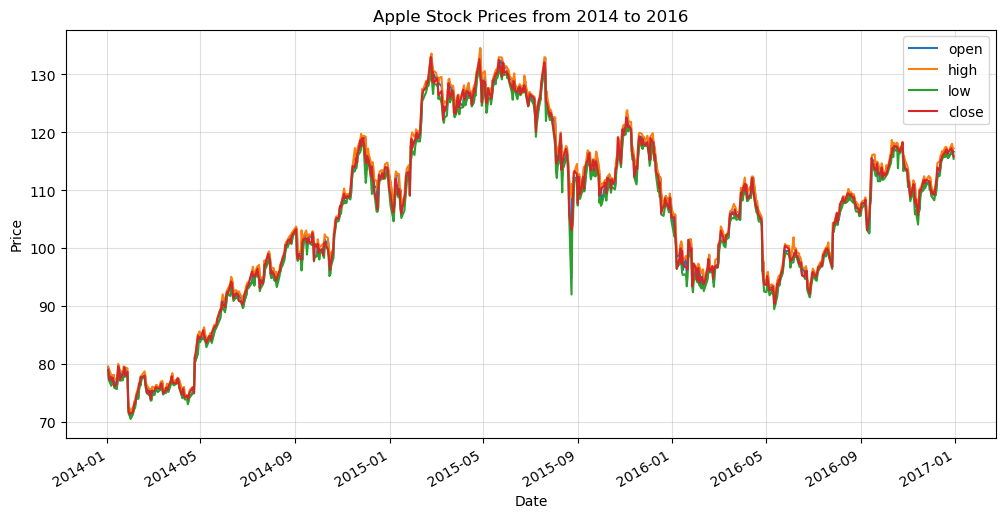

In [7]:
apple_prices = sp500.loc[
    (sp500["Name"] == "AAPL") & (sp500["date"].between("2014-01-01", "2016-12-31")),
    ["date", "open", "high", "low", "close"]
].set_index("date")

ax = apple_prices.plot(figsize=(12, 6), linewidth=1.5)
ax.set_title("Apple Stock Prices from 2014 to 2016")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.grid(True, alpha=0.4)
plt.show()


**Note:** I filter Apple data for the required dates. Then I draw the four price columns on one chart. This helps me compare them directly.


7. which are the top 5 stocks whose closed prices have highest positive/negative correlation with that of Apple?


In [8]:
close_prices = sp500.pivot(index="date", columns="Name", values="close")
apple_close_corr = close_prices.corrwith(close_prices["AAPL"]).drop("AAPL").dropna()

top_5_positive = apple_close_corr.sort_values(ascending=False).head(5)
top_5_negative = apple_close_corr.sort_values().head(5)

print("Top 5 positive correlations with Apple close price:")
print(top_5_positive)
print()
print("Top 5 negative correlations with Apple close price:")
print(top_5_negative)


Top 5 positive correlations with Apple close price:
Name
ANTM    0.968687
MAR     0.964170
MCO     0.957373
ALL     0.950665
RCL     0.948937
dtype: float64

Top 5 negative correlations with Apple close price:
Name
MAT     -0.931754
UA      -0.921523
EVHC    -0.879052
RRC     -0.810863
DISCA   -0.794608
dtype: float64


**Note:** I put each stock close price in a separate column. Then I calculate the correlation with Apple and sort the results.


#### If I need to see the correlation more clearly, then I can also draw the heat map(Top5 positive & negative)


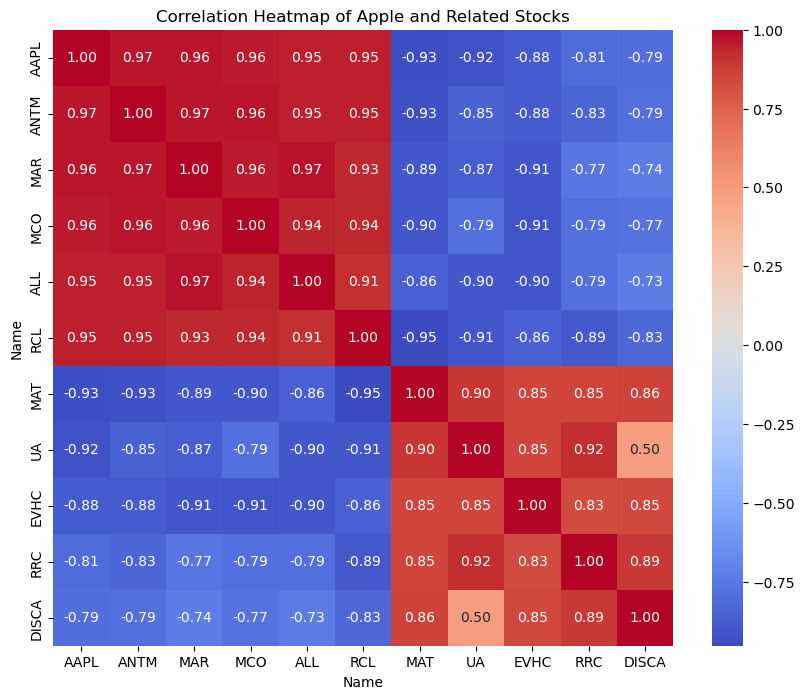

In [9]:
selected_stocks = ["AAPL"] + list(top_5_positive.index) + list(top_5_negative.index)
selected_data = close_prices[selected_stocks]
corr_matrix = selected_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Apple and Related Stocks")
plt.show()


**Note:** The heatmap is an extra check. It makes the correlation result easier to see.


### Question 3 : Data Preparation


8. Deal with the missing data, if there are any of them.


In [10]:
df = sp500.copy()
price_columns = ["open", "high", "low"]

df[price_columns] = (
    df.groupby("Name")[price_columns]
    .transform(lambda group: group.interpolate(method="linear", limit_direction="both"))
)

df.isna().sum()


date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

**Note:** I make a copy before cleaning. I fill the missing prices inside each stock group.


9. Extract the data of Apple, name them as "apple"


In [11]:
apple = df.loc[df["Name"] == "AAPL"].copy()
apple = apple.sort_values("date").reset_index(drop=True)
apple.head()


,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


**Note:** I keep only Apple data for the prediction part. I sort it by date because this is time-series data.


10. Prepare data for training. Write a **pipeline** which consists:

*   An **imputater**: It fills in the missing data with the average of the previous day and the next day.  
*   An **attributesadder**: It adds the prices of previous 5 days as new attributes.
*   An **scaler**: It scales everything numerical data into values between 0 and 1.


In [12]:
class PreviousNextMeanImputer(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, group_col="Name"):
        self.columns = columns
        self.group_col = group_col

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = self.columns or X.select_dtypes(include=[np.number]).columns.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        if self.group_col in X.columns:
            X[self.columns_] = (
                X.groupby(self.group_col, group_keys=False)[self.columns_]
                .apply(lambda group: group.interpolate(method="linear", limit_direction="both"))
            )
        else:
            X[self.columns_] = X[self.columns_].interpolate(method="linear", limit_direction="both")
        return X

imputer_pipeline = Pipeline([
    ("imputer", PreviousNextMeanImputer(columns=["open", "high", "low", "close", "volume"]))
])

apple_imputed = imputer_pipeline.fit_transform(apple)
apple_imputed.head()


,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


**Note:** This cell is for the imputer part. It fills missing values by using nearby days.


In [13]:
class PreviousFiveDaysAdder(BaseEstimator, TransformerMixin):
    def __init__(self, price_col="close", n_days=5):
        self.price_col = price_col
        self.n_days = n_days

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy().sort_values("date").reset_index(drop=True)
        for day in range(1, self.n_days + 1):
            X[f"{self.price_col}_lag_{day}"] = X[self.price_col].shift(day)
        return X.dropna().reset_index(drop=True)

attribute_pipeline = Pipeline([
    ("attributes_adder", PreviousFiveDaysAdder(price_col="close", n_days=5))
])

apple_with_lags = attribute_pipeline.fit_transform(apple_imputed)
apple_with_lags.head()


,date,open,high,low,close,volume,Name,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5
0,2013-02-15,66.9785,67.1656,65.7028,65.7371,97924631,AAPL,66.6556,66.7156,66.8428,68.5614,67.8542
1,2013-02-19,65.8714,66.1042,64.8356,65.7128,108854046,AAPL,65.7371,66.6556,66.7156,66.8428,68.5614
2,2013-02-20,65.3842,65.3842,64.1142,64.1214,118891367,AAPL,65.7128,65.7371,66.6556,66.7156,66.8428
3,2013-02-21,63.7142,64.1671,63.2599,63.7228,111596821,AAPL,64.1214,65.7128,65.7371,66.6556,66.7156
4,2013-02-22,64.1785,64.5142,63.7999,64.4014,82583823,AAPL,63.7228,64.1214,65.7128,65.7371,66.6556


**Note:** This cell adds the previous five closing prices. These new columns will be used as model inputs.


In [14]:
class DataFrameMinMaxScaler(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.numeric_columns_ = X.select_dtypes(include=[np.number]).columns.tolist()
        self.scaler_ = MinMaxScaler()
        self.scaler_.fit(X[self.numeric_columns_])
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X[self.numeric_columns_] = self.scaler_.transform(X[self.numeric_columns_])
        return X

scaler_pipeline = Pipeline([
    ("scaler", DataFrameMinMaxScaler())
])

apple_prepared = scaler_pipeline.fit_transform(apple_with_lags)
apple_prepared.head()


,date,open,high,low,close,volume,Name,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5
0,2013-02-15,0.093221,0.081941,0.086733,0.080564,0.338540,AAPL,0.088003,0.088489,0.089519,0.103438,0.097710
1,2013-02-19,0.084288,0.073313,0.079696,0.080367,0.381340,AAPL,0.080564,0.088003,0.088489,0.089519,0.103438
2,2013-02-20,0.080358,0.067460,0.073842,0.067478,0.420647,AAPL,0.080367,0.080564,0.088003,0.088489,0.089519
3,2013-02-21,0.066884,0.057566,0.066910,0.064250,0.392081,AAPL,0.067478,0.080367,0.080564,0.088003,0.088489
4,2013-02-22,0.070630,0.060387,0.071292,0.069746,0.278464,AAPL,0.064250,0.067478,0.080367,0.080564,0.088003


**Note:** This cell scales the numeric columns. Scaling puts the values between 0 and 1.


11. Divide the datas into train_set and test_set. Remember we are dealing with time series data. Refer [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) for details.


In [15]:
model_data = Pipeline([
    ("imputer", PreviousNextMeanImputer(columns=["open", "high", "low", "close", "volume"])),
    ("attributes_adder", PreviousFiveDaysAdder(price_col="close", n_days=5)),
]).fit_transform(apple)

lag_columns = [f"close_lag_{day}" for day in range(1, 6)]
X = model_data[lag_columns]
y = model_data["close"]

tscv = TimeSeriesSplit(n_splits=5)
train_index, test_index = list(tscv.split(X))[-1]

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]
test_dates = model_data.iloc[test_index]["date"]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print(f"Train dates: {model_data.iloc[train_index]['date'].min().date()} to {model_data.iloc[train_index]['date'].max().date()}")
print(f"Test dates: {model_data.iloc[test_index]['date'].min().date()} to {model_data.iloc[test_index]['date'].max().date()}")


Training rows: 1045
Testing rows: 209
Train dates: 2013-02-15 to 2017-04-10
Test dates: 2017-04-11 to 2018-02-07


**Note:** I use `TimeSeriesSplit` because the order of dates matters. The model should train on earlier data and test on later data.


### Question 4 : Prediction, and Evaluation


12. Using the Linear Regression Model to predict the closed price of Apple by its price in the last 5 days.

*   Report the R-square value
*   Report the mean squared error.
*   Report the equation of regression. In particular, what is the coefficient before the price of the previous day?


R-square: 0.9639
Mean squared error: 4.0889
Regression equation using scaled lag features:
close = 55.9199 + (90.6704 * close_lag_1) + (-2.8063 * close_lag_2) + (0.3185 * close_lag_3) + (-1.2031 * close_lag_4) + (1.8735 * close_lag_5)
Coefficient before previous day's price (close_lag_1): 90.6704


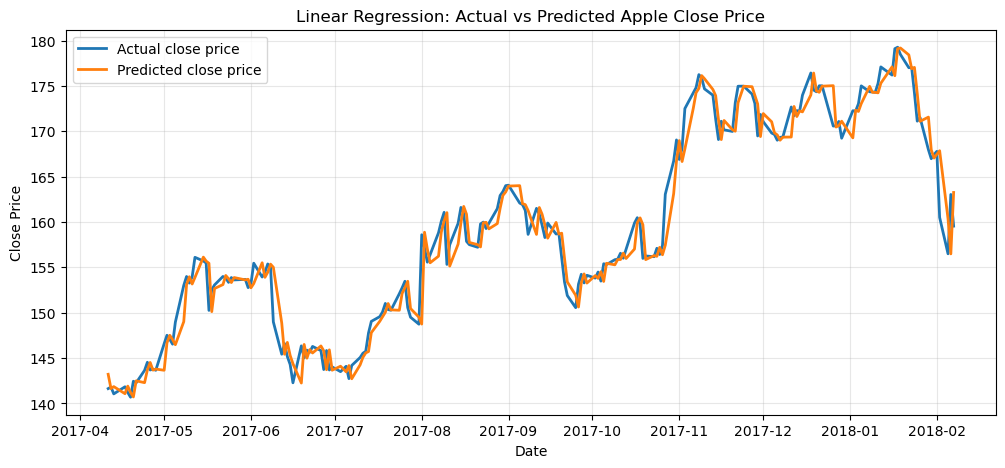

In [16]:
linear_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", LinearRegression()),
])
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_regression = linear_model.named_steps["model"]

print(f"R-square: {r2_score(y_test, linear_pred):.4f}")
print(f"Mean squared error: {mean_squared_error(y_test, linear_pred):.4f}")
print("Regression equation using scaled lag features:")
terms = [f"({coef:.4f} * {feature})" for coef, feature in zip(linear_regression.coef_, lag_columns)]
print(f"close = {linear_regression.intercept_:.4f} + " + " + ".join(terms))
print(f"Coefficient before previous day's price ({lag_columns[0]}): {linear_regression.coef_[0]:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test.values, label="Actual close price", linewidth=2)
plt.plot(test_dates, linear_pred, label="Predicted close price", linewidth=2)
plt.title("Linear Regression: Actual vs Predicted Apple Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Note:** I use linear regression for the first prediction model. The fitted line chart helps me see how close the predicted prices are to the real prices.


13. Using the Decision Tree Regression Model to predict the closed price of Apple by its price in the last 5 days.

*   Report the R-square value
*   Report the mean squared error.
*   Report the features importance.


R-square: -3.1900
Mean squared error: 474.5871
Feature importance:
close_lag_1    0.999436
close_lag_5    0.000564
close_lag_2    0.000000
close_lag_3    0.000000
close_lag_4    0.000000
dtype: float64


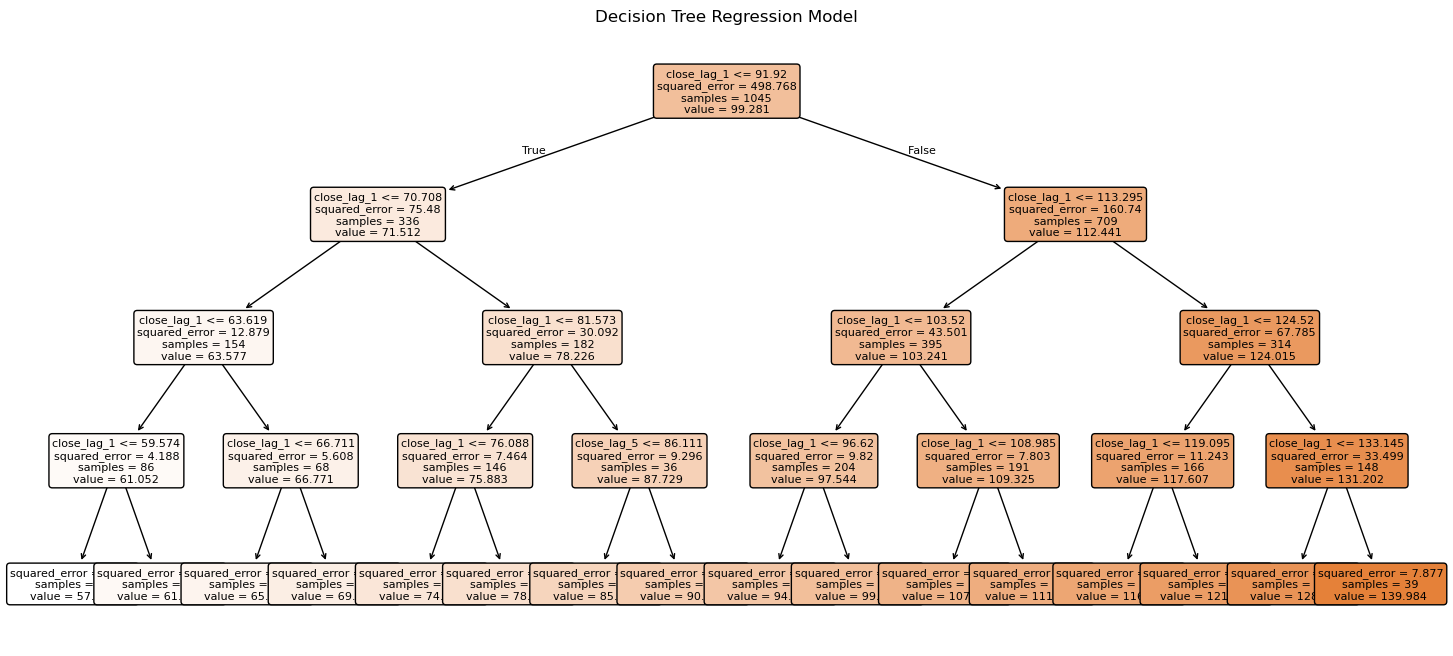

In [17]:
tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print(f"R-square: {r2_score(y_test, tree_pred):.4f}")
print(f"Mean squared error: {mean_squared_error(y_test, tree_pred):.4f}")
print("Feature importance:")
print(pd.Series(tree_model.feature_importances_, index=lag_columns).sort_values(ascending=False))

plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=lag_columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Regression Model")
plt.show()


**Note:** I use a decision tree as the second model. The tree plot shows how the model splits the lag price features.


14. Now instead of predict the price of the next day, predict the price after 5 days, using the two models mentioned before. What are their performances?


In [18]:
future_data = model_data.copy()
future_data["close_after_5_days"] = future_data["close"].shift(-5)
future_data = future_data.dropna(subset=["close_after_5_days"]).reset_index(drop=True)

X_future = future_data[lag_columns]
y_future = future_data["close_after_5_days"]
train_index_5, test_index_5 = list(TimeSeriesSplit(n_splits=5).split(X_future))[-1]

X_train_5, X_test_5 = X_future.iloc[train_index_5], X_future.iloc[test_index_5]
y_train_5, y_test_5 = y_future.iloc[train_index_5], y_future.iloc[test_index_5]

linear_model_5 = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", LinearRegression()),
])
linear_model_5.fit(X_train_5, y_train_5)
linear_pred_5 = linear_model_5.predict(X_test_5)

tree_model_5 = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model_5.fit(X_train_5, y_train_5)
tree_pred_5 = tree_model_5.predict(X_test_5)

performance_after_5_days = pd.DataFrame({
    "model": ["Linear Regression", "Decision Tree Regression"],
    "r_square": [r2_score(y_test_5, linear_pred_5), r2_score(y_test_5, tree_pred_5)],
    "mse": [mean_squared_error(y_test_5, linear_pred_5), mean_squared_error(y_test_5, tree_pred_5)],
})
performance_after_5_days


,model,r_square,mse
0,Linear Regression,0.787656,23.857777
1,Decision Tree Regression,-2.126746,351.303109


**Note:** I change the target to the close price after five days. This is harder than predicting the next day, so the performance may become worse.
